In [1]:
import time
import math
import shap
import pickle
import optuna
import pandas as pd
import numpy as np
import seaborn as sns
import xgboost as xgb
import tensorflow as tf
import matplotlib.pyplot as plt

from scipy.special import ndtri
from decimal import Decimal, ROUND_HALF_UP
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import log_loss, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, validation_curve, cross_val_score, learning_curve

pd.set_option('display.max_columns', 200)

# データの読み込み

In [2]:
df = pd.read_csv('データ抽出.csv')
df

,ID,BD,肝癌症例,Age,Gender,初回治療,No_of_Admission,naïveHCC,初回入院日,入院日,Last_Treatment,basal_disease,etiology,etiology_C1B2BC3Alc4NBNC5,HCV,HBV,nonBnonC,HT,BW,BMI,PS,AST,ALT,Plt,T.Bil,Alb,PT,PT.INR,AFP,L3,PIVKA,FIB4,ALBI_score,ALBI_grade,HCC_size,HCC_No,HCC実数,Vp_grade,Meta0or1,治療法解析用,Death1Alive0,入院日.1,最終観察日_退院日,OS_day,OS_Month,死亡年月日,死因,GNRI,GNRI栄養リスク1良4最悪,男性標準体重,女性標準体重
0,11359162,1925/07/02,1,74.0,1,PEIT,1.0,1.0,2000/04/10,2000/04/10,0,LC,C,1.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,200.0,294.0,10.0,0.9,4.0,98.3,1.01,129.8,NaN,18.0,8.631535,-2.616423,1,3.5,1.0,1,0,0.0,Ablation,1,2000/04/17,2001/12/24,616,20.53333333,2001/12/24,肝癌死,NaN,NaN,NaN,NaN
1,11359162,1925/07/02,1,74.0,1,PEIT,2.0,NaN,2000/04/10,2001/04/17,372,LC,C,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,59.0,53.0,7.8,0.8,4.3,87.0,NaN,2506.0,9.2,NaN,7.688670,-2.905183,1,4,NaN,多発,0,0.0,TAE,1,2001/04/19,2001/12/24,249,8.3,NaN,NaN,NaN,NaN,NaN,NaN
2,11359162,1925/07/02,1,76.0,1,PEIT,3.0,NaN,2000/04/10,2001/08/21,126,LC,C,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,50.0,50.0,7.4,0.7,3.7,105.4,0.98,3408.4,23.2,28.0,7.262178,-2.433458,2a,4,NaN,多発,0,0.0,Ablation,1,2001/08/30,2001/12/24,116,3.866666667,NaN,NaN,NaN,NaN,NaN,NaN
3,20146876,1948/07/02,1,65.0,1,無治療,1.0,1.0,2014/05/08,2014/05/08,0,LC,C,1.0,1.0,0.0,0.0,1.644,50.4,18.64777,0.0,194.0,100.0,19.9,3.6,3.3,74.0,1.17,1020.0,70.9,211840.0,6.336683,-1.624063,2b,6.7,3.0,3,2,0.0,無治療,1,2014/05/08,2014/07/12,65,2.166666667,NaN,肝不全,83.704105,3.0,60.8,NaN
4,13170941,1929/04/19,1,74.0,1,TAE,1.0,1.0,2003/12/02,2003/12/02,0,nonBnonC,nonBnonC,5.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,44.0,16.0,16.5,0.5,3.7,99.6,1.01,3.6,0.0,23.0,4.933333,-2.529902,2a,12,1.0,1,3,0.0,TAE,1,2003/12/04,2004/09/15,286,9.533333333,2004/09/15,肝癌死,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6379,11338154,1925/02/13,1,83.0,1,PEIT,7.0,NaN,NaN,2008/06/02,139,CH,C,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,35.0,30.0,33.0,0.7,4.0,74.1,NaN,5.1,22.8,70.0,1.607206,-2.688458,1,2,3.0,3,0,0.0,Ablation,1,2008/06/02,2011/11/21,1267,42.23333333,NaN,NaN,NaN,NaN,NaN,NaN
6380,11338154,1925/02/13,1,85.0,1,PEIT,8.0,NaN,NaN,2010/03/15,651,CH,C,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,22.0,13.0,20.0,0.4,3.6,84.6,NaN,2.8,18.2,13.0,2.593223,-2.508863,2a,1,1.0,1,0,0.0,TAE,1,2010/03/15,2011/11/21,616,20.53333333,NaN,NaN,NaN,NaN,NaN,NaN
6381,11338154,1925/02/13,1,86.0,1,PEIT,9.0,NaN,NaN,2011/02/21,343,CH,C,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,20.0,17.0,19.4,0.4,3.6,90.2,1.05,7.6,56.4,13.0,2.150316,-2.508863,2a,1.5,2.0,2,0,0.0,TAE,1,2011/02/21,2011/11/21,273,9.1,NaN,NaN,NaN,NaN,NaN,NaN
6382,11338154,1925/02/13,1,86.0,1,PEIT,10.0,NaN,NaN,2011/07/04,133,CH,C,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,29.0,23.0,19.4,0.5,4.0,95.9,1.03,2.5,0.0,9.0,2.680593,-2.784902,1,1,2.0,2,0,0.0,TAE,1,2011/07/04,2011/11/21,140,4.666666667,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6384 entries, 0 to 6383
Data columns (total 51 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID                         6384 non-null   int64  
 1   BD                         6372 non-null   object 
 2   肝癌症例                       6384 non-null   int64  
 3   Age                        6383 non-null   float64
 4   Gender                     6384 non-null   int64  
 5   初回治療                       6381 non-null   object 
 6   No_of_Admission            6364 non-null   float64
 7   naïveHCC                   2008 non-null   float64
 8   初回入院日                      5538 non-null   object 
 9   入院日                        6384 non-null   object 
 10  Last_Treatment             6384 non-null   int64  
 11  basal_disease              6234 non-null   object 
 12  etiology                   6301 non-null   object 
 13  etiology_C1B2BC3Alc4NBNC5  6307 non-null   float

# 前処理

In [4]:
cut = 0

## 治療法

In [5]:
df['治療法解析用'].value_counts()

TAE         2764
Ablation    1685
OPE          806
化学療法         666
無治療          399
放射線治療         48
Name: 治療法解析用, dtype: int64

In [6]:
cut += df['治療法解析用'].isnull().sum()
df['治療法解析用'].isnull().sum()

16

In [7]:
df = df.dropna(subset=['治療法解析用'])

In [8]:
df = pd.get_dummies(df, columns=['治療法解析用'], prefix='', prefix_sep='')
df = df.drop(columns='無治療')
df.rename(columns={'化学療法': 'MTA', '放射線治療': 'Radiation'}, inplace=True)
df

,ID,BD,肝癌症例,Age,Gender,初回治療,No_of_Admission,naïveHCC,初回入院日,入院日,Last_Treatment,basal_disease,etiology,etiology_C1B2BC3Alc4NBNC5,HCV,HBV,nonBnonC,HT,BW,BMI,PS,AST,ALT,Plt,T.Bil,Alb,PT,PT.INR,AFP,L3,PIVKA,FIB4,ALBI_score,ALBI_grade,HCC_size,HCC_No,HCC実数,Vp_grade,Meta0or1,Death1Alive0,入院日.1,最終観察日_退院日,OS_day,OS_Month,死亡年月日,死因,GNRI,GNRI栄養リスク1良4最悪,男性標準体重,女性標準体重,Ablation,OPE,TAE,MTA,Radiation
0,11359162,1925/07/02,1,74.0,1,PEIT,1.0,1.0,2000/04/10,2000/04/10,0,LC,C,1.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,200.0,294.0,10.0,0.9,4.0,98.3,1.01,129.8,NaN,18.0,8.631535,-2.616423,1,3.5,1.0,1,0,0.0,1,2000/04/17,2001/12/24,616,20.53333333,2001/12/24,肝癌死,NaN,NaN,NaN,NaN,1,0,0,0,0
1,11359162,1925/07/02,1,74.0,1,PEIT,2.0,NaN,2000/04/10,2001/04/17,372,LC,C,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,59.0,53.0,7.8,0.8,4.3,87.0,NaN,2506.0,9.2,NaN,7.688670,-2.905183,1,4,NaN,多発,0,0.0,1,2001/04/19,2001/12/24,249,8.3,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,0
2,11359162,1925/07/02,1,76.0,1,PEIT,3.0,NaN,2000/04/10,2001/08/21,126,LC,C,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,50.0,50.0,7.4,0.7,3.7,105.4,0.98,3408.4,23.2,28.0,7.262178,-2.433458,2a,4,NaN,多発,0,0.0,1,2001/08/30,2001/12/24,116,3.866666667,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0,0
3,20146876,1948/07/02,1,65.0,1,無治療,1.0,1.0,2014/05/08,2014/05/08,0,LC,C,1.0,1.0,0.0,0.0,1.644,50.4,18.64777,0.0,194.0,100.0,19.9,3.6,3.3,74.0,1.17,1020.0,70.9,211840.0,6.336683,-1.624063,2b,6.7,3.0,3,2,0.0,1,2014/05/08,2014/07/12,65,2.166666667,NaN,肝不全,83.704105,3.0,60.8,NaN,0,0,0,0,0
4,13170941,1929/04/19,1,74.0,1,TAE,1.0,1.0,2003/12/02,2003/12/02,0,nonBnonC,nonBnonC,5.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,44.0,16.0,16.5,0.5,3.7,99.6,1.01,3.6,0.0,23.0,4.933333,-2.529902,2a,12,1.0,1,3,0.0,1,2003/12/04,2004/09/15,286,9.533333333,2004/09/15,肝癌死,NaN,NaN,NaN,NaN,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6379,11338154,1925/02/13,1,83.0,1,PEIT,7.0,NaN,NaN,2008/06/02,139,CH,C,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,35.0,30.0,33.0,0.7,4.0,74.1,NaN,5.1,22.8,70.0,1.607206,-2.688458,1,2,3.0,3,0,0.0,1,2008/06/02,2011/11/21,1267,42.23333333,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0,0
6380,11338154,1925/02/13,1,85.0,1,PEIT,8.0,NaN,NaN,2010/03/15,651,CH,C,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,22.0,13.0,20.0,0.4,3.6,84.6,NaN,2.8,18.2,13.0,2.593223,-2.508863,2a,1,1.0,1,0,0.0,1,2010/03/15,2011/11/21,616,20.53333333,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,0
6381,11338154,1925/02/13,1,86.0,1,PEIT,9.0,NaN,NaN,2011/02/21,343,CH,C,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,20.0,17.0,19.4,0.4,3.6,90.2,1.05,7.6,56.4,13.0,2.150316,-2.508863,2a,1.5,2.0,2,0,0.0,1,2011/02/21,2011/11/21,273,9.1,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,0
6382,11338154,1925/02/13,1,86.0,1,PEIT,10.0,NaN,NaN,2011/07/04,133,CH,C,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,29.0,23.0,19.4,0.5,4.0,95.9,1.03,2.5,0.0,9.0,2.680593,-2.784902,1,1,2.0,2,0,0.0,1,2011/07/04,2011/11/21,140,4.666666667,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,0


## 前回治療からの期間

In [9]:
cut += df['Last_Treatment'].isnull().sum()
df['Last_Treatment'].isnull().sum()

0

In [10]:
df['Last_Treatment'] = df['Last_Treatment'].replace('#NUM!', 0).replace(0, 10000).astype(int)
df['Last_Treatment'].value_counts()

10000    2324
119       178
126       144
112       138
133       127
         ... 
1385        1
3436        1
1389        1
1393        1
2035        1
Name: Last_Treatment, Length: 942, dtype: int64

<AxesSubplot:>

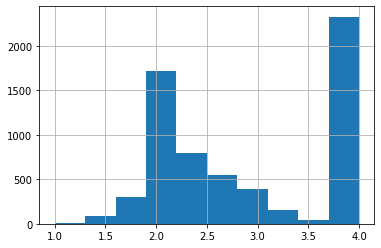

In [11]:
df['Last_Treatment'] = np.log10(df['Last_Treatment'] + 1)
df['Last_Treatment'].hist()

## 年齢

In [12]:
cut += df['Age'].isnull().sum()
df['Age'].isnull().sum()

1

In [13]:
df = df.dropna(subset=['Age'])

## 性別

In [14]:
cut += df['Gender'].isnull().sum()
df['Gender'].isnull().sum()

0

In [15]:
df['Gender'] = df['Gender'].replace(1,  0).replace(2, 1)
df['Gender'].value_counts()


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


0    4772
1    1595
Name: Gender, dtype: int64

## BMI

In [16]:
df['BMI'].isnull().sum()

3987

In [17]:
df['BMI'].mean()

23.55354519539412

In [18]:
df['BMI'] = df['BMI'].fillna(df['BMI'].mean())
df['BMI'].value_counts()


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


23.553545    3987
17.985908       6
19.818927       6
21.504470       5
22.038567       5
             ... 
24.606949       1
21.785199       1
25.834476       1
23.643932       1
19.927729       1
Name: BMI, Length: 2011, dtype: int64

## 手術回数

In [19]:
cut += df['No_of_Admission'].isnull().sum()
df['No_of_Admission'].isnull().sum()

20

In [20]:
df = df.dropna(subset=['No_of_Admission'])
df['No_of_Admission'] = df['No_of_Admission'].astype(int)
df['No_of_Admission'].value_counts()

1     2090
2     1107
3      788
4      585
5      443
6      338
7      254
8      192
9      145
10     116
11      90
12      65
13      41
14      28
15      22
16      15
17      10
18       8
19       4
20       3
21       2
22       1
Name: No_of_Admission, dtype: int64

## 個数

In [21]:
df['HCC_No'].value_counts()

1.0    2376
6.0    1622
2.0     863
3.0     439
4.0     301
5.0     272
0.0      44
2.5       1
Name: HCC_No, dtype: int64

In [22]:
cut += df['HCC_No'].isnull().sum()
df['HCC_No'].isnull().sum()

429

In [23]:
df = df.dropna(subset=['HCC_No'])
df['HCC_No'] = df['HCC_No'].astype(int)
df['HCC_No'].value_counts()

1    2376
6    1622
2     864
3     439
4     301
5     272
0      44
Name: HCC_No, dtype: int64

In [24]:
before = 0
l = []
for i, n in zip(df['ID'], df['HCC_No']):
    if i == before:
        l.append(l[-1] + n)
    else:
        l.append(n)
        before = i

df['No_Cumsum'] = l
df['No_Cumsum'].value_counts()

1     1383
2      730
3      441
6      418
4      312
      ... 
70       2
76       1
86       1
82       1
95       1
Name: No_Cumsum, Length: 91, dtype: int64

## サイズ

In [25]:
df['HCC_size'].value_counts()

1.5     727
1       696
2       430
3       301
2.5     278
       ... 
9.9       1
10.6      1
10.2      1
8.3       1
11.7      1
Name: HCC_size, Length: 145, dtype: int64

In [26]:
cut += df['HCC_size'].isnull().sum()
df['HCC_size'].isnull().sum()

41

In [27]:
df = df.replace('diffuse', '1')
df = df.dropna(subset=['HCC_size'])
df['HCC_size'] = df['HCC_size'].map(lambda x: int(Decimal(str(x)).quantize(Decimal('0'), rounding=ROUND_HALF_UP)))
df['HCC_size'].value_counts()

2     2107
1     1291
3     1013
4      513
5      311
6      162
7      108
8       77
9       61
10      54
0       40
12      33
11      28
13      24
15      22
14      19
16       7
17       3
19       2
18       1
23       1
Name: HCC_size, dtype: int64

## サイズ*個数

In [28]:
df['NoSize'] = df['HCC_No'] * df['HCC_size']
df['NoSize'].value_counts()

2     1058
4      648
6      623
12     609
1      562
3      492
18     352
8      211
24     189
5      174
10     162
30     149
9       97
15      85
36      58
7       48
0       40
16      39
42      35
20      35
48      32
60      23
14      20
13      15
54      14
21      10
11      10
72      10
25       8
66       8
27       7
45       6
78       6
28       6
84       4
22       4
44       4
35       3
32       3
39       2
51       2
33       2
96       2
40       2
70       1
90       1
50       1
26       1
69       1
19       1
17       1
57       1
Name: NoSize, dtype: int64

In [29]:
cut += df['NoSize'].isnull().sum()
df['NoSize'].isnull().sum()

0

In [30]:
before = 0
l = []
for i, n in zip(df['ID'], df['NoSize']):
    if i == before:
        l.append(l[-1] + n)
    else:
        l.append(n)
        before = i

l_10 = [i//10 for i in l]
df['NoSize_Cumsum'] = l_10
df['NoSize_Cumsum'].value_counts()

0     2562
1     1055
2      536
3      414
4      303
5      192
6      182
7      147
8       99
9       77
10      60
11      45
12      39
13      34
15      24
14      24
16      16
17      13
19      13
18       9
21       6
20       5
22       5
23       5
26       3
24       2
27       1
29       1
30       1
25       1
32       1
28       1
31       1
Name: NoSize_Cumsum, dtype: int64

## PS

In [31]:
df['PS'].value_counts()

0.0    1967
1.0     311
2.0     141
3.0     102
4.0      48
Name: PS, dtype: int64

In [32]:
#PSは0埋め
df['PS'] = df['PS'].fillna(0).astype(int)
df['PS_Raw'] = df['PS']
df = pd.get_dummies(df, columns=['PS'])
df = df.drop(columns='PS_0')
df['PS_Raw'].value_counts()

0    5275
1     311
2     141
3     102
4      48
Name: PS_Raw, dtype: int64

## ALBI

In [33]:
df['ALBI_score'].value_counts()

-2.784902    60
-2.647643    55
-2.869902    54
-2.562643    53
-2.348458    51
             ..
-0.571323     1
-1.570283     1
-1.378665     1
-2.927743     1
-1.303582     1
Name: ALBI_score, Length: 801, dtype: int64

In [34]:
cut += df['ALBI_score'].isnull().sum()
df['ALBI_score'].isnull().sum()

78

In [35]:
df = df.dropna(subset=['ALBI_score'])
df['ALBI_score'] = df['ALBI_score'].map(lambda x: int(Decimal(str(x*(-100))).quantize(Decimal('0'), rounding=ROUND_HALF_UP)))
df['ALBI_score'].value_counts()

265    96
236    96
282    85
287    84
259    77
       ..
58      1
46      1
38      1
26      1
367     1
Name: ALBI_score, Length: 308, dtype: int64

## ALBI_grade

In [36]:
df['ALBI_grade'].value_counts()

1     2143
2b    2024
2a    1188
3      444
Name: ALBI_grade, dtype: int64

In [37]:
cut += df['ALBI_grade'].isnull().sum()
df['ALBI_grade'].isnull().sum()

0

In [38]:
df['ALBI_grade'] = df['ALBI_grade'].replace('3', '4').replace('2b', '3').replace('2a', '2').astype(int)
df = pd.get_dummies(df, columns=['ALBI_grade'])
df = df.drop(columns='ALBI_grade_1')
df

,ID,BD,肝癌症例,Age,Gender,初回治療,No_of_Admission,naïveHCC,初回入院日,入院日,Last_Treatment,basal_disease,etiology,etiology_C1B2BC3Alc4NBNC5,HCV,HBV,nonBnonC,HT,BW,BMI,AST,ALT,Plt,T.Bil,Alb,PT,PT.INR,AFP,L3,PIVKA,FIB4,ALBI_score,HCC_size,HCC_No,HCC実数,Vp_grade,Meta0or1,Death1Alive0,入院日.1,最終観察日_退院日,OS_day,OS_Month,死亡年月日,死因,GNRI,GNRI栄養リスク1良4最悪,男性標準体重,女性標準体重,Ablation,OPE,TAE,MTA,Radiation,No_Cumsum,NoSize,NoSize_Cumsum,PS_Raw,PS_1,PS_2,PS_3,PS_4,ALBI_grade_2,ALBI_grade_3,ALBI_grade_4
0,11359162,1925/07/02,1,74.0,0,PEIT,1,1.0,2000/04/10,2000/04/10,4.000043,LC,C,1.0,1.0,0.0,0.0,NaN,NaN,23.553545,200.0,294.0,10.0,0.9,4.0,98.3,1.01,129.8,NaN,18.0,8.631535,262,4,1,1,0,0.0,1,2000/04/17,2001/12/24,616,20.53333333,2001/12/24,肝癌死,NaN,NaN,NaN,NaN,1,0,0,0,0,1,4,0,0,0,0,0,0,0,0,0
3,20146876,1948/07/02,1,65.0,0,無治療,1,1.0,2014/05/08,2014/05/08,4.000043,LC,C,1.0,1.0,0.0,0.0,1.644,50.4,18.647770,194.0,100.0,19.9,3.6,3.3,74.0,1.17,1020.0,70.9,211840.0,6.336683,162,7,3,3,2,0.0,1,2014/05/08,2014/07/12,65,2.166666667,NaN,肝不全,83.704105,3.0,60.80,NaN,0,0,0,0,0,3,21,2,0,0,0,0,0,0,1,0
4,13170941,1929/04/19,1,74.0,0,TAE,1,1.0,2003/12/02,2003/12/02,4.000043,nonBnonC,nonBnonC,5.0,0.0,0.0,1.0,NaN,NaN,23.553545,44.0,16.0,16.5,0.5,3.7,99.6,1.01,3.6,0.0,23.0,4.933333,253,12,1,1,3,0.0,1,2003/12/04,2004/09/15,286,9.533333333,2004/09/15,肝癌死,NaN,NaN,NaN,NaN,0,0,1,0,0,1,12,1,0,0,0,0,0,1,0,0
7,20197511,1936/11/20,1,81.0,0,OPE,1,1.0,2018/02/07,2018/02/07,4.000043,CH,C(DAA SVR),1.0,1.0,0.0,0.0,1.510,51.5,22.586729,27.0,33.0,19.3,0.5,4.3,84.0,1.1,134.3,NaN,62.0,1.972579,304,2,1,1,0,0.0,0,2018/02/07,2022/03/08,1490,49.66666667,NaN,NaN,106.343256,1.0,50.75,NaN,0,1,0,0,0,1,2,0,0,0,0,0,0,0,0,0
8,15371855,1934/02/02,1,69.0,0,RFA,1,1.0,2003/08/04,2003/08/04,4.000043,LC,C,1.0,1.0,0.0,0.0,1.600,55,21.484375,59.0,44.0,22.4,0.9,3.5,87.5,NaN,152.7,35.9,720.0,2.739850,219,3,1,1,0,0.0,1,2003/08/06,2006/04/25,993,33.1,NaN,肝癌死,92.001957,2.0,57.50,NaN,1,0,0,0,0,1,3,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6379,11338154,1925/02/13,1,83.0,0,PEIT,7,NaN,NaN,2008/06/02,2.146128,CH,C,1.0,1.0,NaN,NaN,NaN,NaN,23.553545,35.0,30.0,33.0,0.7,4.0,74.1,NaN,5.1,22.8,70.0,1.607206,269,2,3,3,0,0.0,1,2008/06/02,2011/11/21,1267,42.23333333,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0,0,11,6,2,0,0,0,0,0,0,0,0
6380,11338154,1925/02/13,1,85.0,0,PEIT,8,NaN,NaN,2010/03/15,2.814248,CH,C,1.0,1.0,NaN,NaN,NaN,NaN,23.553545,22.0,13.0,20.0,0.4,3.6,84.6,NaN,2.8,18.2,13.0,2.593223,251,1,1,1,0,0.0,1,2010/03/15,2011/11/21,616,20.53333333,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,0,12,1,2,0,0,0,0,0,1,0,0
6381,11338154,1925/02/13,1,86.0,0,PEIT,9,NaN,NaN,2011/02/21,2.536558,CH,C,1.0,1.0,NaN,NaN,NaN,NaN,23.553545,20.0,17.0,19.4,0.4,3.6,90.2,1.05,7.6,56.4,13.0,2.150316,251,2,2,2,0,0.0,1,2011/02/21,2011/11/21,273,9.1,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,0,14,4,2,0,0,0,0,0,1,0,0
6382,11338154,1925/02/13,1,86.0,0,PEIT,10,NaN,NaN,2011/07/04,2.127105,CH,C,1.0,1.0,NaN,NaN,NaN,NaN,23.553545,29.0,23.0,19.4,0.5,4.0,95.9,1.03,2.5,0.0,9.0,2.680593,278,1,2,2,0,0.0,1,2011/07/04,2011/11/21,140,4.666666667,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,0,16,2,3,0,0,0,0,0,0,0,0


## AFP

In [39]:
#cut += df['AFP'].isnull().sum()
df['AFP'].isnull().sum()

50

In [40]:
#AFPは0埋め
df['AFP'] = df['AFP'].fillna(0).astype(float)
df.insert(loc=0, column='AFP_100', value= -1)
df.loc[df['AFP'] < 100, 'AFP_100'] = 0
df.loc[~(df['AFP'] < 100), 'AFP_100'] = 1
df['AFP_100'].value_counts()

0    4029
1    1770
Name: AFP_100, dtype: int64

## L3

In [41]:
#cut += df['L3'].isnull().sum()
df['L3'].isnull().sum()

454

In [42]:
#L3は0埋め
df['L3'] = df['L3'].fillna(0).astype(float)
df.insert(loc=0, column='L3_10', value= -1)
df.loc[df['L3'] < 10, 'L3_10'] = 0
df.loc[~(df['L3'] < 10), 'L3_10'] = 1
df['L3_10'].value_counts()

0    3752
1    2047
Name: L3_10, dtype: int64

In [43]:
df['L3_10'] = df['L3_10'].fillna(0).astype(int)
df['L3_10'].value_counts()

0    3752
1    2047
Name: L3_10, dtype: int64

## PIVKA

In [44]:
#cut += df['PIVKA'].isnull().sum()
df['PIVKA'].isnull().sum()

120

In [45]:
#PIVKAは0埋め
df['PIVKA'] = df['PIVKA'].fillna(0).astype(float)
df.insert(loc=0, column='PIVKA_100', value= -1)
df.loc[df['PIVKA'] < 100, 'PIVKA_100'] = 0
df.loc[~(df['PIVKA'] < 100), 'PIVKA_100'] = 1
df['PIVKA_100'].value_counts()

0    3105
1    2694
Name: PIVKA_100, dtype: int64

## Vp_grade

In [46]:
df['Vp_grade'].value_counts()

0    5413
2     139
3     105
4      99
1      43
Name: Vp_grade, dtype: int64

In [47]:
cut += df['Vp_grade'].isnull().sum()
df['Vp_grade'].isnull().sum()

0

In [48]:
df['Vp_grade'] = df['Vp_grade'].replace(2,  1).replace(3, 1).replace(4, 1)
df['Vp_grade'].value_counts()

0    5413
1     386
Name: Vp_grade, dtype: int64

## meta_positive

In [49]:
df['Meta0or1'].value_counts()

0.0    5430
1.0     338
2.0       1
Name: Meta0or1, dtype: int64

In [50]:
cut += df['Meta0or1'].isnull().sum()
df['Meta0or1'].isnull().sum()

30

In [51]:
df = df.dropna(subset=['Meta0or1'])
df['Meta0or1'] = df['Meta0or1'].replace(2, 1).astype(int)
df['Meta0or1'].value_counts()


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


0    5430
1     339
Name: Meta0or1, dtype: int64

## etiology

In [52]:
df['etiology_C1B2BC3Alc4NBNC5'].value_counts()

1.0    3834
5.0     921
4.0     472
2.0     462
3.0      70
Name: etiology_C1B2BC3Alc4NBNC5, dtype: int64

In [53]:
cut += df['etiology_C1B2BC3Alc4NBNC5'].isnull().sum()
df['etiology_C1B2BC3Alc4NBNC5'].isnull().sum()

10

In [54]:
df = df.dropna(subset=['etiology_C1B2BC3Alc4NBNC5'])
df = df.rename(columns={'etiology_C1B2BC3Alc4NBNC5': 'etiology_class'})
df['etiology_class'] = df['etiology_class'].replace(1,  'C').replace(2, 'B').replace(3, 'BC').replace(4, 'Alc').replace(5, 'NBNC')
df['etiology_class'].value_counts()

C       3834
NBNC     921
Alc      472
B        462
BC        70
Name: etiology_class, dtype: int64

In [55]:
df = pd.get_dummies(df, columns=['etiology_class'])
df.loc[df['etiology_class_BC'] == 1, 'etiology_class_B'] = 1
df.loc[df['etiology_class_BC'] == 1, 'etiology_class_C'] = 1
df = df.drop(columns=['etiology_class_BC', 'etiology_class_NBNC'])
df

,PIVKA_100,L3_10,AFP_100,ID,BD,肝癌症例,Age,Gender,初回治療,No_of_Admission,naïveHCC,初回入院日,入院日,Last_Treatment,basal_disease,etiology,HCV,HBV,nonBnonC,HT,BW,BMI,AST,ALT,Plt,T.Bil,Alb,PT,PT.INR,AFP,L3,PIVKA,FIB4,ALBI_score,HCC_size,HCC_No,HCC実数,Vp_grade,Meta0or1,Death1Alive0,入院日.1,最終観察日_退院日,OS_day,OS_Month,死亡年月日,死因,GNRI,GNRI栄養リスク1良4最悪,男性標準体重,女性標準体重,Ablation,OPE,TAE,MTA,Radiation,No_Cumsum,NoSize,NoSize_Cumsum,PS_Raw,PS_1,PS_2,PS_3,PS_4,ALBI_grade_2,ALBI_grade_3,ALBI_grade_4,etiology_class_Alc,etiology_class_B,etiology_class_C
0,0,0,1,11359162,1925/07/02,1,74.0,0,PEIT,1,1.0,2000/04/10,2000/04/10,4.000043,LC,C,1.0,0.0,0.0,NaN,NaN,23.553545,200.0,294.0,10.0,0.9,4.0,98.3,1.01,129.8,0.0,18.0,8.631535,262,4,1,1,0,0,1,2000/04/17,2001/12/24,616,20.53333333,2001/12/24,肝癌死,NaN,NaN,NaN,NaN,1,0,0,0,0,1,4,0,0,0,0,0,0,0,0,0,0,0,1
3,1,1,1,20146876,1948/07/02,1,65.0,0,無治療,1,1.0,2014/05/08,2014/05/08,4.000043,LC,C,1.0,0.0,0.0,1.644,50.4,18.647770,194.0,100.0,19.9,3.6,3.3,74.0,1.17,1020.0,70.9,211840.0,6.336683,162,7,3,3,1,0,1,2014/05/08,2014/07/12,65,2.166666667,NaN,肝不全,83.704105,3.0,60.80,NaN,0,0,0,0,0,3,21,2,0,0,0,0,0,0,1,0,0,0,1
4,0,0,0,13170941,1929/04/19,1,74.0,0,TAE,1,1.0,2003/12/02,2003/12/02,4.000043,nonBnonC,nonBnonC,0.0,0.0,1.0,NaN,NaN,23.553545,44.0,16.0,16.5,0.5,3.7,99.6,1.01,3.6,0.0,23.0,4.933333,253,12,1,1,1,0,1,2003/12/04,2004/09/15,286,9.533333333,2004/09/15,肝癌死,NaN,NaN,NaN,NaN,0,0,1,0,0,1,12,1,0,0,0,0,0,1,0,0,0,0,0
7,0,0,1,20197511,1936/11/20,1,81.0,0,OPE,1,1.0,2018/02/07,2018/02/07,4.000043,CH,C(DAA SVR),1.0,0.0,0.0,1.510,51.5,22.586729,27.0,33.0,19.3,0.5,4.3,84.0,1.1,134.3,0.0,62.0,1.972579,304,2,1,1,0,0,0,2018/02/07,2022/03/08,1490,49.66666667,NaN,NaN,106.343256,1.0,50.75,NaN,0,1,0,0,0,1,2,0,0,0,0,0,0,0,0,0,0,0,1
8,1,1,1,15371855,1934/02/02,1,69.0,0,RFA,1,1.0,2003/08/04,2003/08/04,4.000043,LC,C,1.0,0.0,0.0,1.600,55,21.484375,59.0,44.0,22.4,0.9,3.5,87.5,NaN,152.7,35.9,720.0,2.739850,219,3,1,1,0,0,1,2003/08/06,2006/04/25,993,33.1,NaN,肝癌死,92.001957,2.0,57.50,NaN,1,0,0,0,0,1,3,0,0,0,0,0,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6379,0,1,0,11338154,1925/02/13,1,83.0,0,PEIT,7,NaN,NaN,2008/06/02,2.146128,CH,C,1.0,NaN,NaN,NaN,NaN,23.553545,35.0,30.0,33.0,0.7,4.0,74.1,NaN,5.1,22.8,70.0,1.607206,269,2,3,3,0,0,1,2008/06/02,2011/11/21,1267,42.23333333,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0,0,11,6,2,0,0,0,0,0,0,0,0,0,0,1
6380,0,1,0,11338154,1925/02/13,1,85.0,0,PEIT,8,NaN,NaN,2010/03/15,2.814248,CH,C,1.0,NaN,NaN,NaN,NaN,23.553545,22.0,13.0,20.0,0.4,3.6,84.6,NaN,2.8,18.2,13.0,2.593223,251,1,1,1,0,0,1,2010/03/15,2011/11/21,616,20.53333333,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,0,12,1,2,0,0,0,0,0,1,0,0,0,0,1
6381,0,1,0,11338154,1925/02/13,1,86.0,0,PEIT,9,NaN,NaN,2011/02/21,2.536558,CH,C,1.0,NaN,NaN,NaN,NaN,23.553545,20.0,17.0,19.4,0.4,3.6,90.2,1.05,7.6,56.4,13.0,2.150316,251,2,2,2,0,0,1,2011/02/21,2011/11/21,273,9.1,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,0,14,4,2,0,0,0,0,0,1,0,0,0,0,1
6382,0,0,0,11338154,1925/02/13,1,86.0,0,PEIT,10,NaN,NaN,2011/07/04,2.127105,CH,C,1.0,NaN,NaN,NaN,NaN,23.553545,29.0,23.0,19.4,0.5,4.0,95.9,1.03,2.5,0.0,9.0,2.680593,278,1,2,2,0,0,1,2011/07/04,2011/11/21,140,4.666666667,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,0,16,2,3,0,0,0,0,0,0,0,0,0,0,1


## OS

In [56]:
df['OS_day'] = df['OS_day'].replace('#VALUE!', np.nan).replace('#REF!', np.nan)
cut += df['OS_day'].isnull().sum()
df['OS_day'].isnull().sum()

7

In [57]:
df = df.dropna(subset=['OS_day'])
df['OS_day'] = df['OS_day'].astype(int)
df['OS_day'].unique()


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


array([ 616,   65,  286, ..., 2035, 1775, 1406])

## 肝臓がんのみを抽出

In [58]:
df['肝癌症例'].value_counts()

1    5701
0      51
Name: 肝癌症例, dtype: int64

In [59]:
cut += len(df[df['肝癌症例']==0])
len(df[df['肝癌症例']==0])

51

In [60]:
df = df[df['肝癌症例'] == 1]

## dfとcutの確認

In [61]:
df

,PIVKA_100,L3_10,AFP_100,ID,BD,肝癌症例,Age,Gender,初回治療,No_of_Admission,naïveHCC,初回入院日,入院日,Last_Treatment,basal_disease,etiology,HCV,HBV,nonBnonC,HT,BW,BMI,AST,ALT,Plt,T.Bil,Alb,PT,PT.INR,AFP,L3,PIVKA,FIB4,ALBI_score,HCC_size,HCC_No,HCC実数,Vp_grade,Meta0or1,Death1Alive0,入院日.1,最終観察日_退院日,OS_day,OS_Month,死亡年月日,死因,GNRI,GNRI栄養リスク1良4最悪,男性標準体重,女性標準体重,Ablation,OPE,TAE,MTA,Radiation,No_Cumsum,NoSize,NoSize_Cumsum,PS_Raw,PS_1,PS_2,PS_3,PS_4,ALBI_grade_2,ALBI_grade_3,ALBI_grade_4,etiology_class_Alc,etiology_class_B,etiology_class_C
0,0,0,1,11359162,1925/07/02,1,74.0,0,PEIT,1,1.0,2000/04/10,2000/04/10,4.000043,LC,C,1.0,0.0,0.0,NaN,NaN,23.553545,200.0,294.0,10.0,0.9,4.0,98.3,1.01,129.8,0.0,18.0,8.631535,262,4,1,1,0,0,1,2000/04/17,2001/12/24,616,20.53333333,2001/12/24,肝癌死,NaN,NaN,NaN,NaN,1,0,0,0,0,1,4,0,0,0,0,0,0,0,0,0,0,0,1
3,1,1,1,20146876,1948/07/02,1,65.0,0,無治療,1,1.0,2014/05/08,2014/05/08,4.000043,LC,C,1.0,0.0,0.0,1.644,50.4,18.647770,194.0,100.0,19.9,3.6,3.3,74.0,1.17,1020.0,70.9,211840.0,6.336683,162,7,3,3,1,0,1,2014/05/08,2014/07/12,65,2.166666667,NaN,肝不全,83.704105,3.0,60.80,NaN,0,0,0,0,0,3,21,2,0,0,0,0,0,0,1,0,0,0,1
4,0,0,0,13170941,1929/04/19,1,74.0,0,TAE,1,1.0,2003/12/02,2003/12/02,4.000043,nonBnonC,nonBnonC,0.0,0.0,1.0,NaN,NaN,23.553545,44.0,16.0,16.5,0.5,3.7,99.6,1.01,3.6,0.0,23.0,4.933333,253,12,1,1,1,0,1,2003/12/04,2004/09/15,286,9.533333333,2004/09/15,肝癌死,NaN,NaN,NaN,NaN,0,0,1,0,0,1,12,1,0,0,0,0,0,1,0,0,0,0,0
7,0,0,1,20197511,1936/11/20,1,81.0,0,OPE,1,1.0,2018/02/07,2018/02/07,4.000043,CH,C(DAA SVR),1.0,0.0,0.0,1.510,51.5,22.586729,27.0,33.0,19.3,0.5,4.3,84.0,1.1,134.3,0.0,62.0,1.972579,304,2,1,1,0,0,0,2018/02/07,2022/03/08,1490,49.66666667,NaN,NaN,106.343256,1.0,50.75,NaN,0,1,0,0,0,1,2,0,0,0,0,0,0,0,0,0,0,0,1
8,1,1,1,15371855,1934/02/02,1,69.0,0,RFA,1,1.0,2003/08/04,2003/08/04,4.000043,LC,C,1.0,0.0,0.0,1.600,55,21.484375,59.0,44.0,22.4,0.9,3.5,87.5,NaN,152.7,35.9,720.0,2.739850,219,3,1,1,0,0,1,2003/08/06,2006/04/25,993,33.1,NaN,肝癌死,92.001957,2.0,57.50,NaN,1,0,0,0,0,1,3,0,0,0,0,0,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6379,0,1,0,11338154,1925/02/13,1,83.0,0,PEIT,7,NaN,NaN,2008/06/02,2.146128,CH,C,1.0,NaN,NaN,NaN,NaN,23.553545,35.0,30.0,33.0,0.7,4.0,74.1,NaN,5.1,22.8,70.0,1.607206,269,2,3,3,0,0,1,2008/06/02,2011/11/21,1267,42.23333333,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0,0,11,6,2,0,0,0,0,0,0,0,0,0,0,1
6380,0,1,0,11338154,1925/02/13,1,85.0,0,PEIT,8,NaN,NaN,2010/03/15,2.814248,CH,C,1.0,NaN,NaN,NaN,NaN,23.553545,22.0,13.0,20.0,0.4,3.6,84.6,NaN,2.8,18.2,13.0,2.593223,251,1,1,1,0,0,1,2010/03/15,2011/11/21,616,20.53333333,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,0,12,1,2,0,0,0,0,0,1,0,0,0,0,1
6381,0,1,0,11338154,1925/02/13,1,86.0,0,PEIT,9,NaN,NaN,2011/02/21,2.536558,CH,C,1.0,NaN,NaN,NaN,NaN,23.553545,20.0,17.0,19.4,0.4,3.6,90.2,1.05,7.6,56.4,13.0,2.150316,251,2,2,2,0,0,1,2011/02/21,2011/11/21,273,9.1,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,0,14,4,2,0,0,0,0,0,1,0,0,0,0,1
6382,0,0,0,11338154,1925/02/13,1,86.0,0,PEIT,10,NaN,NaN,2011/07/04,2.127105,CH,C,1.0,NaN,NaN,NaN,NaN,23.553545,29.0,23.0,19.4,0.5,4.0,95.9,1.03,2.5,0.0,9.0,2.680593,278,1,2,2,0,0,1,2011/07/04,2011/11/21,140,4.666666667,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,0,16,2,3,0,0,0,0,0,0,0,0,0,0,1


In [62]:
cut

683

## 1yearの作成

In [65]:
df['Death1Alive0'] = df['Death1Alive0'].astype(int)
df.insert(loc=0, column='1year', value= -1)
df.loc[(df['OS_day'] < 365) & (df['Death1Alive0'] == 1), '1year'] = 0
df.loc[df['OS_day'] >= 365, '1year'] = 1
df['1year'].value_counts()

 1    3956
 0     988
-1     757
Name: 1year, dtype: int64

In [66]:
## 1年後の生死が未確認（OS.day<365&Death1Alive0=0)を削除
df = df[df['1year'] != -1]

## 学習データ

In [67]:
data = df.loc[:,['Ablation', 'OPE', 'TAE', 'MTA', 'Radiation', 'Last_Treatment', 'Age', 'Gender', 'BMI', 'No_of_Admission', 'HCC_No', 'No_Cumsum', 
                 'HCC_size', 'NoSize', 'NoSize_Cumsum', 'PS_Raw', 'PS_1', 'PS_2', 'PS_3', 'PS_4', 'ALBI_score', 'AFP_100', 'L3_10', 'PIVKA_100', 
                 'Vp_grade', 'Meta0or1', 'etiology_class_C', 'etiology_class_B', 'etiology_class_Alc']]
target = df['1year']
data

,Ablation,OPE,TAE,MTA,Radiation,Last_Treatment,Age,Gender,BMI,No_of_Admission,HCC_No,No_Cumsum,HCC_size,NoSize,NoSize_Cumsum,PS_Raw,PS_1,PS_2,PS_3,PS_4,ALBI_score,AFP_100,L3_10,PIVKA_100,Vp_grade,Meta0or1,etiology_class_C,etiology_class_B,etiology_class_Alc
0,1,0,0,0,0,4.000043,74.0,0,23.553545,1,1,1,4,4,0,0,0,0,0,0,262,1,0,0,0,0,1,0,0
3,0,0,0,0,0,4.000043,65.0,0,18.647770,1,3,3,7,21,2,0,0,0,0,0,162,1,1,1,1,0,1,0,0
4,0,0,1,0,0,4.000043,74.0,0,23.553545,1,1,1,12,12,1,0,0,0,0,0,253,0,0,0,1,0,0,0,0
7,0,1,0,0,0,4.000043,81.0,0,22.586729,1,1,1,2,2,0,0,0,0,0,0,304,1,0,0,0,0,1,0,0
8,1,0,0,0,0,4.000043,69.0,0,21.484375,1,1,1,3,3,0,0,0,0,0,0,219,1,1,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6378,1,0,0,0,0,2.262451,82.0,0,23.553545,6,1,8,1,1,1,0,0,0,0,0,285,0,0,0,0,0,1,0,0
6379,1,0,0,0,0,2.146128,83.0,0,23.553545,7,3,11,2,6,2,0,0,0,0,0,269,0,1,0,0,0,1,0,0
6380,0,0,1,0,0,2.814248,85.0,0,23.553545,8,1,12,1,1,2,0,0,0,0,0,251,0,1,0,0,0,1,0,0
6381,0,0,1,0,0,2.536558,86.0,0,23.553545,9,2,14,2,4,2,0,0,0,0,0,251,0,1,0,0,0,1,0,0


In [68]:
data.dtypes

Ablation                uint8
OPE                     uint8
TAE                     uint8
MTA                     uint8
Radiation               uint8
Last_Treatment        float64
Age                   float64
Gender                  int64
BMI                   float64
No_of_Admission         int64
HCC_No                  int64
No_Cumsum               int64
HCC_size                int64
NoSize                  int64
NoSize_Cumsum           int64
PS_Raw                  int64
PS_1                    uint8
PS_2                    uint8
PS_3                    uint8
PS_4                    uint8
ALBI_score              int64
AFP_100                 int64
L3_10                   int64
PIVKA_100               int64
Vp_grade                int64
Meta0or1                int64
etiology_class_C        uint8
etiology_class_B        uint8
etiology_class_Alc      uint8
dtype: object

# TrainとValidの作成

In [69]:
from sklearn.model_selection import train_test_split

x_train, x_valid, y_train, y_valid = train_test_split(data, target, train_size = 0.8, random_state = 5)

In [70]:
x_train.head()

,Ablation,OPE,TAE,MTA,Radiation,Last_Treatment,Age,Gender,BMI,No_of_Admission,HCC_No,No_Cumsum,HCC_size,NoSize,NoSize_Cumsum,PS_Raw,PS_1,PS_2,PS_3,PS_4,ALBI_score,AFP_100,L3_10,PIVKA_100,Vp_grade,Meta0or1,etiology_class_C,etiology_class_B,etiology_class_Alc
3036,0,1,0,0,0,4.000043,77.0,1,25.414247,1,1,1,1,1,0,1,1,0,0,0,177,0,0,0,0,0,1,0,0
6030,0,0,1,0,0,2.103804,74.0,1,21.504470,3,3,13,2,6,2,0,0,0,0,0,228,0,0,0,0,0,1,0,0
952,1,0,0,0,0,2.894316,78.0,0,23.553545,2,2,3,2,4,1,0,0,0,0,0,278,0,0,1,0,0,0,0,0
5100,0,0,1,0,0,3.286456,73.0,1,23.553545,6,5,12,2,10,2,0,0,0,0,0,222,0,1,0,0,0,1,0,0
6283,0,0,1,0,0,4.000043,83.0,1,26.985466,1,4,4,1,4,0,0,0,0,0,0,202,0,0,0,0,0,1,0,0


# GBDT

In [67]:
X = data.drop(['PS_1', 'PS_2', 'PS_3', 'PS_4'], axis=1)
Y = target.values.ravel()

model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', eta=0.05, max_depth=4, use_label_encoder=False)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = cross_validate(model, X, Y, scoring=['neg_log_loss', 'roc_auc'], cv=kfold)

print(results)
print()
print('LogLoss :', np.mean(results['test_neg_log_loss'])*-1)
print('AUC :', np.mean(results['test_roc_auc']))

{'fit_time': array([0.36805868, 0.45649099, 0.32885408, 0.45347095, 0.34094119]), 'score_time': array([0.01155519, 0.00854492, 0.00906086, 0.00854897, 0.01185155]), 'test_neg_log_loss': array([-0.33999112, -0.35000342, -0.35035404, -0.35761233, -0.33555434]), 'test_roc_auc': array([0.87260038, 0.86675031, 0.85111982, 0.84162729, 0.87798445])}

LogLoss : 0.3467030528841265
AUC : 0.8620164509445234


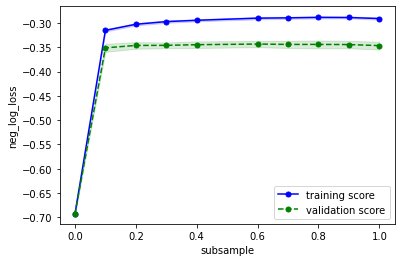

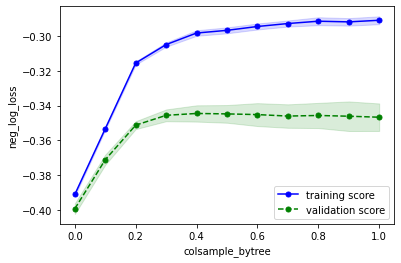

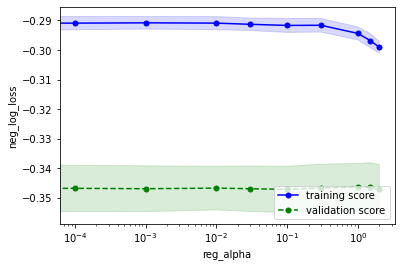

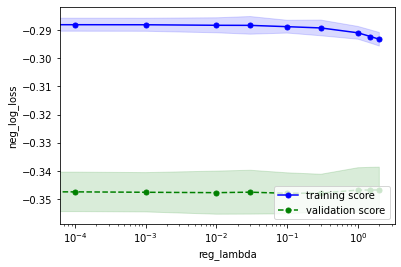

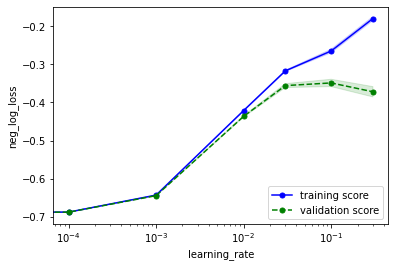

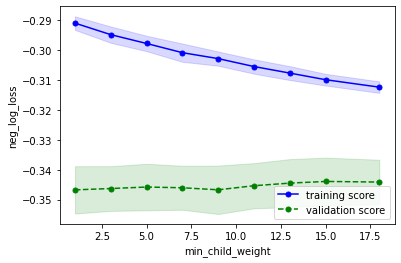

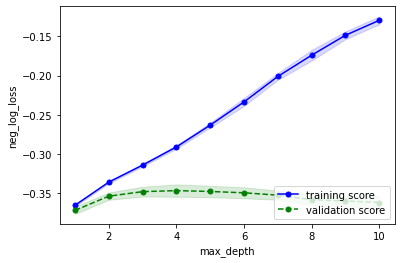

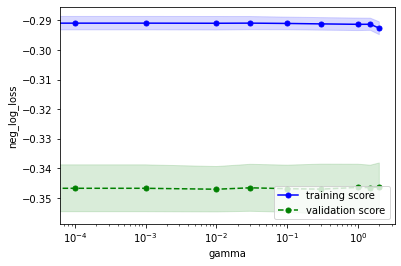

In [68]:
cv_params = {'subsample': [0, 0.1, 0.2, 0.3, 0.4, 0.6, 0.7, 0.8, 0.9, 1.0],
             'colsample_bytree': [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
             'reg_alpha': [0, 0.0001, 0.001, 0.01, 0.03, 0.1, 0.3, 1.0, 1.5, 2.0],
             'reg_lambda': [0, 0.0001, 0.001, 0.01, 0.03, 0.1, 0.3, 1.0, 1.5, 2.0],
             'learning_rate': [0, 0.0001, 0.001, 0.01, 0.03, 0.1, 0.3, 1.0],
             'min_child_weight': [1, 3, 5, 7, 9, 11, 13, 15, 18],
             'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
             'gamma': [0, 0.0001, 0.001, 0.01, 0.03, 0.1, 0.3, 1.0, 1.5, 2.0]
             }
param_scales = {'subsample': 'linear',
                'colsample_bytree': 'linear',
                'reg_alpha': 'log',
                'reg_lambda': 'log',
                'learning_rate': 'log',
                'min_child_weight': 'linear',
                'max_depth': 'linear',
                'gamma': 'log'
                }
fit_params = {'verbose': 0,  'early_stopping_rounds': 20,  'eval_metric': 'logloss',  'eval_set': [(X, Y)]}
scoring = 'neg_log_loss'

# 検証曲線のプロット（パラメータ毎にプロット）
for i, (k, v) in enumerate(cv_params.items()):
    train_scores, valid_scores = validation_curve(estimator=model,
                                                  X=X, y=Y,
                                                  param_name=k,
                                                  param_range=v,
                                                  fit_params=fit_params,
                                                  cv=kfold, scoring=scoring,
                                                  n_jobs=-1)
    # 学習データに対するスコアの平均±標準偏差を算出
    train_mean = np.mean(train_scores, axis=1)
    train_std  = np.std(train_scores, axis=1)
    train_center = train_mean
    train_high = train_mean + train_std
    train_low = train_mean - train_std
    # テストデータに対するスコアの平均±標準偏差を算出
    valid_mean = np.mean(valid_scores, axis=1)
    valid_std  = np.std(valid_scores, axis=1)
    valid_center = valid_mean
    valid_high = valid_mean + valid_std
    valid_low = valid_mean - valid_std
    # training_scoresをプロット
    plt.plot(v, train_center, color='blue', marker='o', markersize=5, label='training score')
    plt.fill_between(v, train_high, train_low, alpha=0.15, color='blue')
    # validation_scoresをプロット
    plt.plot(v, valid_center, color='green', linestyle='--', marker='o', markersize=5, label='validation score')
    plt.fill_between(v, valid_high, valid_low, alpha=0.15, color='green')
    # スケールをparam_scalesに合わせて変更
    plt.xscale(param_scales[k])
    # 軸ラベルおよび凡例の指定
    plt.xlabel(k)  # パラメータ名を横軸ラベルに
    plt.ylabel(scoring)  # スコア名を縦軸ラベルに
    plt.legend(loc='lower right')  # 凡例
    # グラフを描画
    plt.show()

In [69]:
start = time.time()

# ベイズ最適化時の評価指標算出メソッド
def bayes_objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.5, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 2, 8),
        'max_depth': trial.suggest_int('max_depth', 2, 6),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.2, 1.0),
        'subsample': trial.suggest_float('subsample', 0.2, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.001, 0.1, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0001, 0.1, log=True),
        'gamma': trial.suggest_float('gamma', 0.0001, 0.1, log=True),
    }
    # モデルにパラメータ適用
    model.set_params(**params)
    # cross_val_scoreでクロスバリデーション
    scores = cross_val_score(model, X, Y, cv=kfold,
                             scoring=scoring, fit_params=fit_params, n_jobs=-1)
    val = scores.mean()
    return val

# ベイズ最適化を実行
study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(bayes_objective, n_trials=600)

# 最適パラメータの表示と保持
best_params = study.best_trial.params
best_score = study.best_trial.value
print(f'最適パラメータ {best_params}\nスコア {best_score}')
print(f'所要時間{time.time() - start}秒')

[I 2023-01-04 09:40:29,886] A new study created in memory with name: no-name-9844818c-9a97-4232-aeb6-17f4b1b71bb6
[I 2023-01-04 09:40:32,424] Trial 0 finished with value: -0.34452458970069344 and parameters: {'learning_rate': 0.043284502212938815, 'min_child_weight': 8, 'max_depth': 5, 'colsample_bytree': 0.6789267873576292, 'subsample': 0.3248149123539492, 'reg_alpha': 0.002051110418843397, 'reg_lambda': 0.00014936568554617635, 'gamma': 0.0396760507705299}. Best is trial 0 with value: -0.34452458970069344.
[I 2023-01-04 09:40:34,261] Trial 1 finished with value: -0.34476612173721427 and parameters: {'learning_rate': 0.10502105436744279, 'min_child_weight': 6, 'max_depth': 2, 'colsample_bytree': 0.9759278817295955, 'subsample': 0.8659541126403374, 'reg_alpha': 0.0026587543983272706, 'reg_lambda': 0.0003511356313970409, 'gamma': 0.0003549878832196505}. Best is trial 0 with value: -0.34452458970069344.
[I 2023-01-04 09:40:36,448] Trial 2 finished with value: -0.3507833130014995 and param

[I 2023-01-04 09:41:23,188] Trial 20 finished with value: -0.3665344782450135 and parameters: {'learning_rate': 0.020488579394530436, 'min_child_weight': 6, 'max_depth': 5, 'colsample_bytree': 0.7481693495882199, 'subsample': 0.5454862287997415, 'reg_alpha': 0.009797728981516944, 'reg_lambda': 0.00010344480950753545, 'gamma': 0.000836107086731204}. Best is trial 0 with value: -0.34452458970069344.
[I 2023-01-04 09:41:25,192] Trial 21 finished with value: -0.34425257683723204 and parameters: {'learning_rate': 0.05898690944674034, 'min_child_weight': 6, 'max_depth': 5, 'colsample_bytree': 0.6729372283002797, 'subsample': 0.31780908773343713, 'reg_alpha': 0.0010250427635464232, 'reg_lambda': 0.0987475410057757, 'gamma': 0.00019665572919741223}. Best is trial 21 with value: -0.34425257683723204.
[I 2023-01-04 09:41:26,802] Trial 22 finished with value: -0.3500891856878151 and parameters: {'learning_rate': 0.09274429631384074, 'min_child_weight': 4, 'max_depth': 4, 'colsample_bytree': 0.590

[I 2023-01-04 09:42:07,640] Trial 40 finished with value: -0.3515054735035609 and parameters: {'learning_rate': 0.10762075219231038, 'min_child_weight': 3, 'max_depth': 4, 'colsample_bytree': 0.8112598116145523, 'subsample': 0.4236579408474688, 'reg_alpha': 0.0019027166097729416, 'reg_lambda': 0.0164746724705688, 'gamma': 0.0001488490432445506}. Best is trial 24 with value: -0.3432210704933855.
[I 2023-01-04 09:42:10,272] Trial 41 finished with value: -0.3480538910327698 and parameters: {'learning_rate': 0.03421564516640681, 'min_child_weight': 7, 'max_depth': 5, 'colsample_bytree': 0.7110294499399527, 'subsample': 0.3027252856525015, 'reg_alpha': 0.0011639254712921625, 'reg_lambda': 0.0001746013747346653, 'gamma': 0.00045289199529783956}. Best is trial 24 with value: -0.3432210704933855.
[I 2023-01-04 09:42:12,210] Trial 42 finished with value: -0.34661901769776604 and parameters: {'learning_rate': 0.055546246271920466, 'min_child_weight': 4, 'max_depth': 5, 'colsample_bytree': 0.6510

[I 2023-01-04 09:43:00,321] Trial 60 finished with value: -0.35519442481466135 and parameters: {'learning_rate': 0.04201577281351755, 'min_child_weight': 4, 'max_depth': 5, 'colsample_bytree': 0.2110364936871113, 'subsample': 0.772330630943976, 'reg_alpha': 0.005702926474174918, 'reg_lambda': 0.00013339161762272427, 'gamma': 0.0019106544053579518}. Best is trial 24 with value: -0.3432210704933855.
[I 2023-01-04 09:43:02,883] Trial 61 finished with value: -0.3427665697615276 and parameters: {'learning_rate': 0.06153345419967131, 'min_child_weight': 5, 'max_depth': 6, 'colsample_bytree': 0.6833530216711828, 'subsample': 0.6538852419525396, 'reg_alpha': 0.024614157451312874, 'reg_lambda': 0.0016926071224422183, 'gamma': 0.0014046195629333917}. Best is trial 61 with value: -0.3427665697615276.
[I 2023-01-04 09:43:05,438] Trial 62 finished with value: -0.34393146879701997 and parameters: {'learning_rate': 0.050165131228921814, 'min_child_weight': 5, 'max_depth': 6, 'colsample_bytree': 0.671

[I 2023-01-04 09:43:37,029] Trial 80 finished with value: -0.34549560968819243 and parameters: {'learning_rate': 0.08277500006489134, 'min_child_weight': 6, 'max_depth': 2, 'colsample_bytree': 0.5825630634930589, 'subsample': 0.700238026013149, 'reg_alpha': 0.04574315759409857, 'reg_lambda': 0.022372408862481305, 'gamma': 0.0037107471909219635}. Best is trial 69 with value: -0.34251871127747335.
[I 2023-01-04 09:43:38,585] Trial 81 finished with value: -0.34837835350147667 and parameters: {'learning_rate': 0.13486702004694867, 'min_child_weight': 4, 'max_depth': 3, 'colsample_bytree': 0.4613412189002307, 'subsample': 0.7850902718546738, 'reg_alpha': 0.058208578794477224, 'reg_lambda': 0.005756022844143401, 'gamma': 0.006190046925232185}. Best is trial 69 with value: -0.34251871127747335.
[I 2023-01-04 09:43:39,999] Trial 82 finished with value: -0.34423726021780177 and parameters: {'learning_rate': 0.06618920192434881, 'min_child_weight': 4, 'max_depth': 3, 'colsample_bytree': 0.510433

...

[I 2023-01-04 10:00:40,250] Trial 520 finished with value: -0.3426868253408061 and parameters: {'learning_rate': 0.06548989466738242, 'min_child_weight': 6, 'max_depth': 4, 'colsample_bytree': 0.6793270402337946, 'subsample': 0.7606877753104957, 'reg_alpha': 0.021510349232715577, 'reg_lambda': 0.009174550719079333, 'gamma': 0.00024701122795615433}. Best is trial 362 with value: -0.34168703602869793.
[I 2023-01-04 10:00:42,373] Trial 521 finished with value: -0.34245618431200253 and parameters: {'learning_rate': 0.07123847437347036, 'min_child_weight': 6, 'max_depth': 4, 'colsample_bytree': 0.5468132684854079, 'subsample': 0.7982150794328469, 'reg_alpha': 0.025386811132051646, 'reg_lambda': 0.00590726501941548, 'gamma': 0.00028244229629124565}. Best is trial 362 with value: -0.34168703602869793.
[I 2023-01-04 10:00:45,101] Trial 522 finished with value: -0.3434853761277555 and parameters: {'learning_rate': 0.08578669128670216, 'min_child_weight': 6, 'max_depth': 4, 'colsample_bytree': 0

[I 2023-01-04 10:01:27,473] Trial 540 finished with value: -0.34319229020009423 and parameters: {'learning_rate': 0.05977804731492568, 'min_child_weight': 6, 'max_depth': 3, 'colsample_bytree': 0.5719890395929366, 'subsample': 0.7799561420695216, 'reg_alpha': 0.015940113490868706, 'reg_lambda': 0.01475112169960942, 'gamma': 0.0003263200965482698}. Best is trial 362 with value: -0.34168703602869793.
[I 2023-01-04 10:01:30,534] Trial 541 finished with value: -0.34332050624786464 and parameters: {'learning_rate': 0.06731142566740655, 'min_child_weight': 6, 'max_depth': 4, 'colsample_bytree': 0.6903990267323697, 'subsample': 0.7963722322395984, 'reg_alpha': 0.0256025421123339, 'reg_lambda': 0.009574880992327865, 'gamma': 0.00046201588898639977}. Best is trial 362 with value: -0.34168703602869793.
[I 2023-01-04 10:01:32,952] Trial 542 finished with value: -0.34300354332901317 and parameters: {'learning_rate': 0.052867161118036216, 'min_child_weight': 6, 'max_depth': 4, 'colsample_bytree': 0

[I 2023-01-04 10:02:14,850] Trial 560 finished with value: -0.3420560517948991 and parameters: {'learning_rate': 0.05973348085970556, 'min_child_weight': 6, 'max_depth': 4, 'colsample_bytree': 0.5834319771868555, 'subsample': 0.777037128501825, 'reg_alpha': 0.03567384717116314, 'reg_lambda': 0.00016460226195011716, 'gamma': 0.021510682057714208}. Best is trial 362 with value: -0.34168703602869793.
[I 2023-01-04 10:02:16,706] Trial 561 finished with value: -0.34289758698258144 and parameters: {'learning_rate': 0.04880864868715441, 'min_child_weight': 6, 'max_depth': 4, 'colsample_bytree': 0.5740450597264786, 'subsample': 0.7627038508511303, 'reg_alpha': 0.039050046784223046, 'reg_lambda': 0.0029636100232174304, 'gamma': 0.0002726018022061058}. Best is trial 362 with value: -0.34168703602869793.
[I 2023-01-04 10:02:18,504] Trial 562 finished with value: -0.3422909482063701 and parameters: {'learning_rate': 0.0587639975048312, 'min_child_weight': 6, 'max_depth': 4, 'colsample_bytree': 0.5

[I 2023-01-04 10:03:04,187] Trial 580 finished with value: -0.3424514342731831 and parameters: {'learning_rate': 0.05912659128631531, 'min_child_weight': 6, 'max_depth': 4, 'colsample_bytree': 0.5511451251657823, 'subsample': 0.7585451497549148, 'reg_alpha': 0.025994789656951595, 'reg_lambda': 0.0040706842060538265, 'gamma': 0.0001237592372472714}. Best is trial 362 with value: -0.34168703602869793.
[I 2023-01-04 10:03:05,968] Trial 581 finished with value: -0.3423345892038102 and parameters: {'learning_rate': 0.07187475558751394, 'min_child_weight': 6, 'max_depth': 4, 'colsample_bytree': 0.5312735025394189, 'subsample': 0.7817635466987628, 'reg_alpha': 0.019337297121284645, 'reg_lambda': 0.004772421475898547, 'gamma': 0.0014663004124532853}. Best is trial 362 with value: -0.34168703602869793.
[I 2023-01-04 10:03:08,217] Trial 582 finished with value: -0.34194764543619893 and parameters: {'learning_rate': 0.05478432289352926, 'min_child_weight': 6, 'max_depth': 4, 'colsample_bytree': 0

最適パラメータ {'learning_rate': 0.059836814462728274, 'min_child_weight': 6, 'max_depth': 4, 'colsample_bytree': 0.6516692872889185, 'subsample': 0.7890301990126464, 'reg_alpha': 0.02302404792701629, 'reg_lambda': 0.007010379529438841, 'gamma': 0.0005546002070011629}
スコア -0.34168703602869793
所要時間1394.5552442073822秒


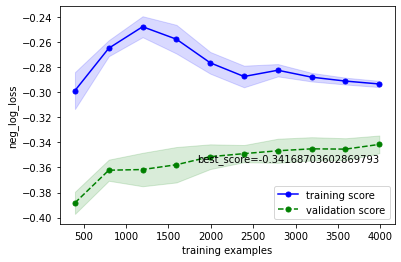

In [70]:
# 最適パラメータを学習器にセット
model.set_params(**best_params)

# 学習曲線の取得
train_sizes, train_scores, valid_scores = learning_curve(estimator=model,
                                                         X=X, y=Y,
                                                         train_sizes=np.linspace(0.1, 1.0, 10),
                                                         fit_params=fit_params,
                                                         cv=kfold, scoring=scoring, n_jobs=-1)
# 学習データ指標の平均±標準偏差を計算
train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
train_center = train_mean
train_high = train_mean + train_std
train_low = train_mean - train_std
# 検証データ指標の平均±標準偏差を計算
valid_mean = np.mean(valid_scores, axis=1)
valid_std  = np.std(valid_scores, axis=1)
valid_center = valid_mean
valid_high = valid_mean + valid_std
valid_low = valid_mean - valid_std
# training_scoresをプロット
plt.plot(train_sizes, train_center, color='blue', marker='o', markersize=5, label='training score')
plt.fill_between(train_sizes, train_high, train_low, alpha=0.15, color='blue')
# validation_scoresをプロット
plt.plot(train_sizes, valid_center, color='green', linestyle='--', marker='o', markersize=5, label='validation score')
plt.fill_between(train_sizes, valid_high, valid_low, alpha=0.15, color='green')
# 最高スコアの表示
best_score = valid_center[len(valid_center) - 1]
plt.text(np.amax(train_sizes), valid_low[len(valid_low) - 1], f'best_score={best_score}',
                color='black', verticalalignment='top', horizontalalignment='right')
# 軸ラベルおよび凡例の指定
plt.xlabel('training examples')  # 学習サンプル数を横軸ラベルに
plt.ylabel(scoring)  # スコア名を縦軸ラベルに
plt.legend(loc='lower right')  # 凡例

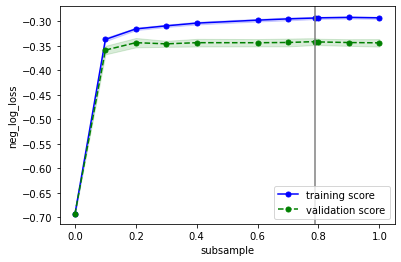

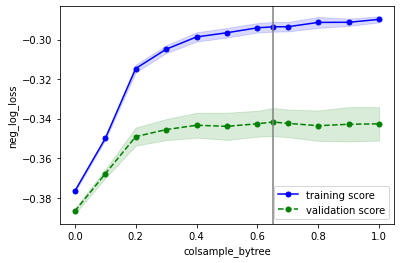

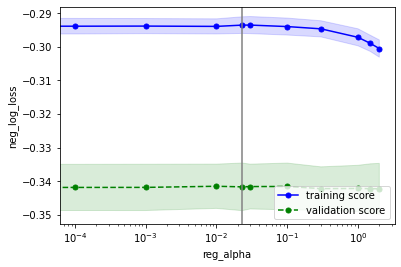

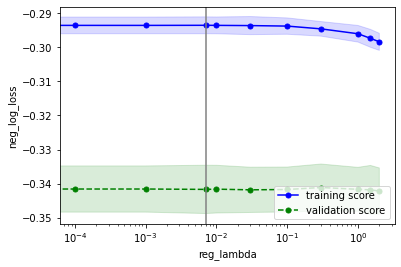

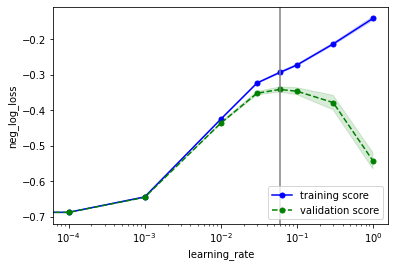

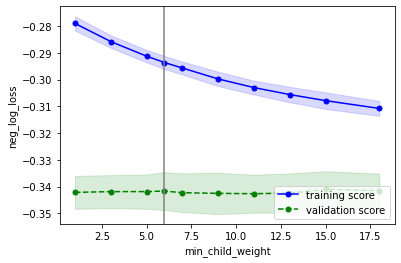

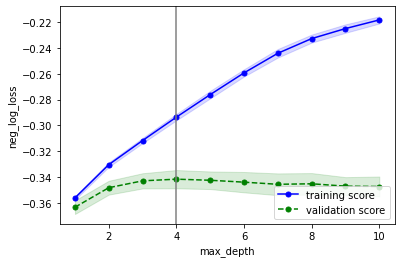

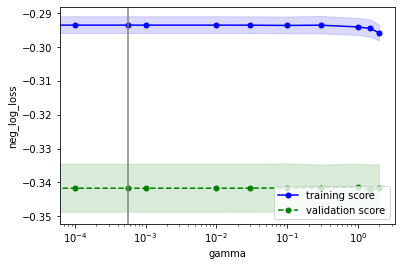

In [71]:
valid_curve_params = {'subsample': [0, 0.1, 0.2, 0.3, 0.4, 0.6, 0.7, 0.8, 0.9, 1.0],
             'colsample_bytree': [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
             'reg_alpha': [0, 0.0001, 0.001, 0.01, 0.03, 0.1, 0.3, 1.0, 1.5, 2.0],
             'reg_lambda': [0, 0.0001, 0.001, 0.01, 0.03, 0.1, 0.3, 1.0, 1.5, 2.0],
             'learning_rate': [0, 0.0001, 0.001, 0.01, 0.03, 0.1, 0.3, 1.0],
             'min_child_weight': [1, 3, 5, 7, 9, 11, 13, 15, 18],
             'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
             'gamma': [0, 0.0001, 0.001, 0.01, 0.03, 0.1, 0.3, 1.0, 1.5, 2.0]
             }

for k, v in valid_curve_params.items():
    if best_params[k] not in v:
        v.append(best_params[k])
        v.sort()
for i, (k, v) in enumerate(valid_curve_params.items()):
    # モデルに最適パラメータを適用
    model.set_params(**best_params)
    # 検証曲線を描画
    train_scores, valid_scores = validation_curve(estimator=model,
                                                  X=X, y=Y,
                                                  param_name=k,
                                                  param_range=v,
                                                  fit_params=fit_params,
                                                  cv=kfold, scoring=scoring,
                                                  n_jobs=-1)
    # 学習データに対するスコアの平均±標準偏差を算出
    train_mean = np.mean(train_scores, axis=1)
    train_std  = np.std(train_scores, axis=1)
    train_center = train_mean
    train_high = train_mean + train_std
    train_low = train_mean - train_std
    # テストデータに対するスコアの平均±標準偏差を算出
    valid_mean = np.mean(valid_scores, axis=1)
    valid_std  = np.std(valid_scores, axis=1)
    valid_center = valid_mean
    valid_high = valid_mean + valid_std
    valid_low = valid_mean - valid_std
    # training_scoresをプロット
    plt.plot(v, train_center, color='blue', marker='o', markersize=5, label='training score')
    plt.fill_between(v, train_high, train_low, alpha=0.15, color='blue')
    # validation_scoresをプロット
    plt.plot(v, valid_center, color='green', linestyle='--', marker='o', markersize=5, label='validation score')
    plt.fill_between(v, valid_high, valid_low, alpha=0.15, color='green')
    # 最適パラメータを縦線表示
    plt.axvline(x=best_params[k], color='gray')
    # スケールをparam_scalesに合わせて変更
    plt.xscale(param_scales[k])
    # 軸ラベルおよび凡例の指定
    plt.xlabel(k)  # パラメータ名を横軸ラベルに
    plt.ylabel(scoring)  # スコア名を縦軸ラベルに
    plt.legend(loc='lower right')  # 凡例
    # グラフを描画
    plt.show()

In [71]:
x_train_gbdt = x_train.drop(['PS_1', 'PS_2', 'PS_3', 'PS_4'], axis=1)
x_valid_gbdt = x_valid.drop(['PS_1', 'PS_2', 'PS_3', 'PS_4'], axis=1)

dtrain = xgb.DMatrix(x_train_gbdt, label=y_train)
dvalid = xgb.DMatrix(x_valid_gbdt, label=y_valid)
x_train_gbdt.head()

,Ablation,OPE,TAE,MTA,Radiation,Last_Treatment,Age,Gender,BMI,No_of_Admission,HCC_No,No_Cumsum,HCC_size,NoSize,NoSize_Cumsum,PS_Raw,ALBI_score,AFP_100,L3_10,PIVKA_100,Vp_grade,Meta0or1,etiology_class_C,etiology_class_B,etiology_class_Alc
3036,0,1,0,0,0,4.000043,77.0,1,25.414247,1,1,1,1,1,0,1,177,0,0,0,0,0,1,0,0
6030,0,0,1,0,0,2.103804,74.0,1,21.504470,3,3,13,2,6,2,0,228,0,0,0,0,0,1,0,0
952,1,0,0,0,0,2.894316,78.0,0,23.553545,2,2,3,2,4,1,0,278,0,0,1,0,0,0,0,0
5100,0,0,1,0,0,3.286456,73.0,1,23.553545,6,5,12,2,10,2,0,222,0,1,0,0,0,1,0,0
6283,0,0,1,0,0,4.000043,83.0,1,26.985466,1,4,4,1,4,0,0,202,0,0,0,0,0,1,0,0


In [72]:
best_params = {'learning_rate': 0.05811461859916969, 'min_child_weight': 3, 'max_depth': 4, 'colsample_bytree': 0.6635312112868554, 
               'subsample': 0.7363826915307297, 'reg_alpha': 0.03974099424691413, 'reg_lambda': 0.00010222170608885958, 'gamma': 0.028945262488630805}

In [73]:
params = {'objective': 'binary:logistic', 'eval_metric': 'logloss', 'booster': 'gbtree'} | best_params
num_round = 1000
watchlist = [(dtrain, 'train'), (dvalid, 'eval')]
evals_result = {}
model_GBDT = xgb.train(params, dtrain, num_round, early_stopping_rounds=20, evals=watchlist, evals_result=evals_result)

[0]	train-logloss:0.66219	eval-logloss:0.66364
[1]	train-logloss:0.63445	eval-logloss:0.63720
[2]	train-logloss:0.60934	eval-logloss:0.61264
[3]	train-logloss:0.58707	eval-logloss:0.59072
[4]	train-logloss:0.56707	eval-logloss:0.57193
[5]	train-logloss:0.54904	eval-logloss:0.55556
[6]	train-logloss:0.53212	eval-logloss:0.53934
[7]	train-logloss:0.51630	eval-logloss:0.52442
[8]	train-logloss:0.50157	eval-logloss:0.51072
[9]	train-logloss:0.48781	eval-logloss:0.49791
[10]	train-logloss:0.47560	eval-logloss:0.48629
[11]	train-logloss:0.46474	eval-logloss:0.47666
[12]	train-logloss:0.45396	eval-logloss:0.46729
[13]	train-logloss:0.44487	eval-logloss:0.45867
[14]	train-logloss:0.43594	eval-logloss:0.45040
[15]	train-logloss:0.42817	eval-logloss:0.44262
[16]	train-logloss:0.42079	eval-logloss:0.43592
[17]	train-logloss:0.41330	eval-logloss:0.42916
[18]	train-logloss:0.40657	eval-logloss:0.42282
[19]	train-logloss:0.40097	eval-logloss:0.41785
[20]	train-logloss:0.39482	eval-logloss:0.41334
[2

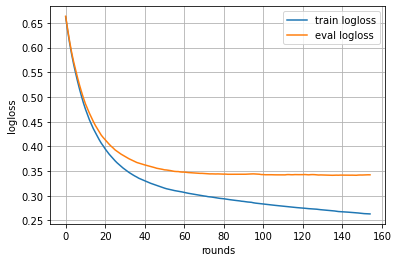

In [74]:
#trainデータに対してのloss推移をplot
plt.plot(evals_result['train']['logloss'], label='train logloss')
#validデータに対してのloss推移をplot
plt.plot(evals_result['eval']['logloss'], label='eval logloss')
plt.grid()
plt.legend()
plt.xlabel('rounds')
plt.ylabel('logloss')
plt.show()

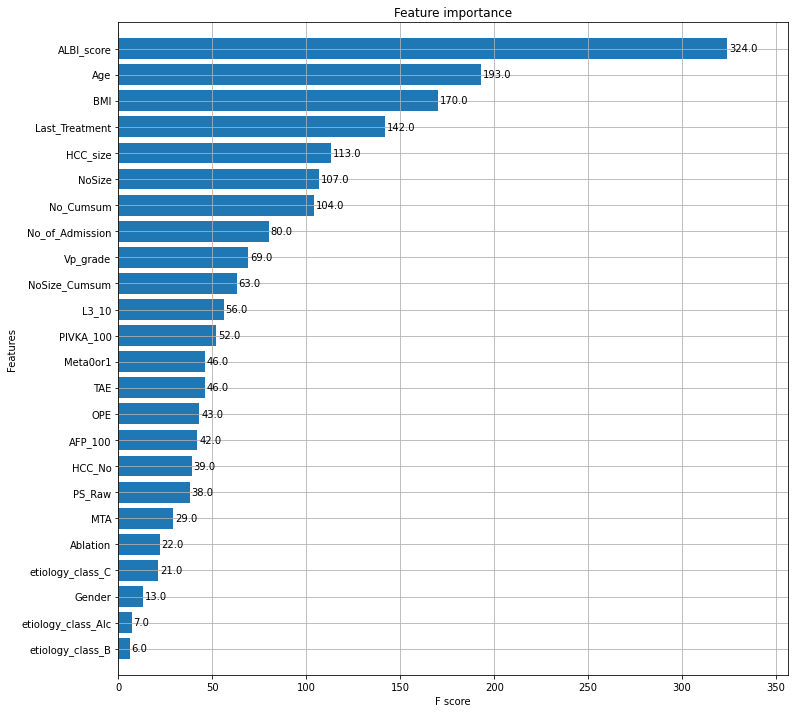

In [75]:
git, ax = plt.subplots(figsize=(12, 12))
xgb.plot_importance(model_GBDT, height=0.8, ax=ax)
#plt.savefig('1021_Feature_Importance_1year.jpg', dpi=300)
plt.show()

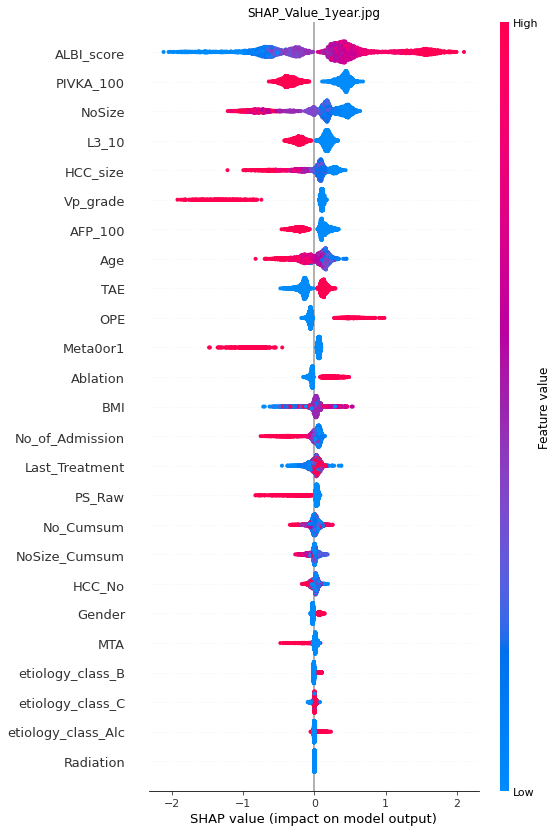

In [112]:
explainer = shap.TreeExplainer(model_GBDT)
shap_values = explainer.shap_values(x_train_gbdt)
shap.summary_plot(shap_values, x_train_gbdt, max_display=100, show=False)
plt.title('SHAP_Value_1year.jpg')
#plt.savefig('results/0111_Feature_Importance_1year_SHAP.jpg', dpi=300)
plt.show()

In [77]:
y_valid

6306    1
1497    1
975     1
4915    1
2352    1
       ..
4204    1
4813    0
6350    1
1320    1
3521    0
Name: 1year, Length: 989, dtype: int64

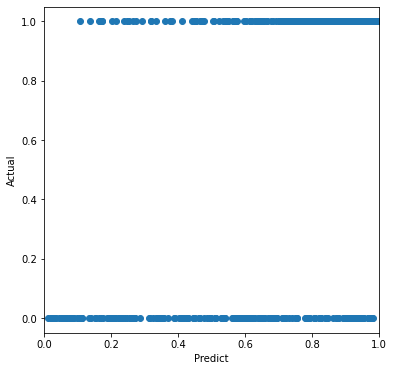

In [78]:
pred_GBDT = model_GBDT.predict(dvalid)

plt.figure(figsize=(6, 6))
plt.xlabel("Predict")
plt.ylabel("Actual")
plt.xlim(0, 1)
plt.scatter(pred_GBDT, y_valid)
plt.show()

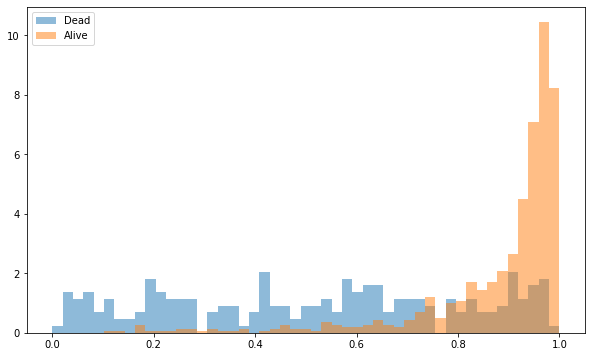

In [79]:
zero, one = [], []

for i in range(len(pred_GBDT)):
    if y_valid.iloc[i] == 0:
        zero.append(pred_GBDT[i])
    else:
        one.append(pred_GBDT[i])
        
plt.figure(figsize=(10, 6))
bins = np.linspace(0, 1, 50)

plt.hist(zero, bins, alpha = 0.5, label='Dead', density = True)
plt.hist(one, bins, alpha = 0.5, label='Alive', density = True)
plt.legend(loc='upper left')

plt.show()

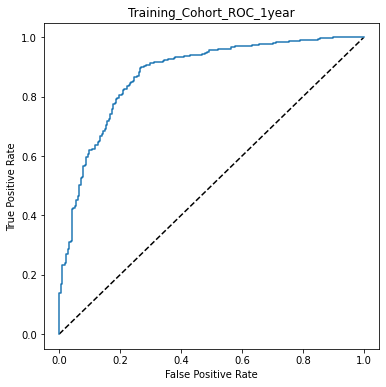

0.8752358632293733


In [114]:
# ROC曲線の値の生成：fpr、tpr、閾値
fpr, tpr, thresholds = roc_curve(y_valid, pred_GBDT)

# ROC曲線のプロット
plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr, label='Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Training_Cohort_ROC_1year')
#plt.savefig('results/0111_Valid_ROC_1year.jpg', dpi=300)
plt.show()

#AUCの表示
auc_GBDT = roc_auc_score(y_valid, pred_GBDT)
print(auc_GBDT)

In [81]:
print(y_valid.values.tolist()[:20])

[1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0]


In [82]:
print(np.round(pred_GBDT).astype(int).tolist()[:20])

[1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0]


In [83]:
cm = confusion_matrix(y_valid.values.tolist(), np.round(pred_GBDT).astype(int).tolist())
cm

array([[100, 115],
       [ 29, 745]])

In [84]:
def roc_auc_ci(y_true, y_score, positive=1):
    AUC = roc_auc_score(y_true, y_score)
    N1 = sum(y_true == positive)
    N2 = sum(y_true != positive)
    Q1 = AUC / (2 - AUC)
    Q2 = 2*AUC**2 / (1 + AUC)
    SE_AUC = math.sqrt((AUC*(1 - AUC) + (N1 - 1)*(Q1 - AUC**2) + (N2 - 1)*(Q2 - AUC**2)) / (N1*N2))
    lower = AUC - 1.96*SE_AUC
    upper = AUC + 1.96*SE_AUC
    if lower < 0:
        lower = 0
    if upper > 1:
        upper = 1
    return (lower, upper)

roc_auc_ci(y_valid, pred_GBDT)

(0.8535458575728322, 0.8969258688859144)

In [85]:
def _proportion_confidence_interval(r, n, z):
    A = 2*r + z**2
    B = z*math.sqrt(z**2 + 4*r*(1 - r/n))
    C = 2*(n + z**2)
    return ((A-B)/C, (A+B)/C)

def sensitivity_and_specificity_with_confidence_intervals(TP, FP, FN, TN, alpha):
    
    z = -ndtri((1.0-alpha)/2)
    
    sensitivity_point_estimate = TP/(TP + FN)
    sensitivity_confidence_interval = _proportion_confidence_interval(TP, TP + FN, z)
    
    specificity_point_estimate = TN/(TN + FP)
    specificity_confidence_interval = _proportion_confidence_interval(TN, TN + FP, z)
    
    return sensitivity_point_estimate, specificity_point_estimate, sensitivity_confidence_interval, specificity_confidence_interval

sensitivity_and_specificity_with_confidence_intervals(cm[1][1], cm[0][1], cm[1][0], cm[0][0], 0.95)

(0.962532299741602,
 0.46511627906976744,
 (0.9467083329208034, 0.9737877294587287),
 (0.39964216892195975, 0.5318150600654867))

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).


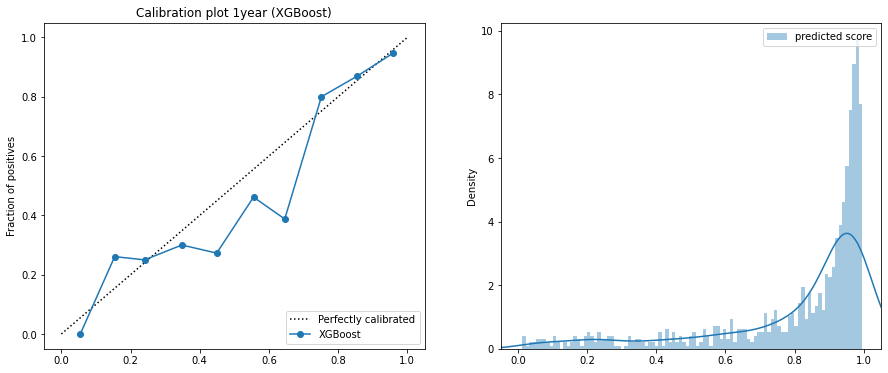

In [115]:
def viz_calibration_curve(y_test, y_pred, name):
    frac_of_pos, mean_pred_value = calibration_curve(y_test, y_pred, n_bins=10)

    fig, ax = plt.subplots(1, 2, figsize=(15,6))
    ax[0].plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
    ax[0].plot(mean_pred_value, frac_of_pos, marker="o", label=f'{name}')
    ax[0].set_ylabel("Fraction of positives")
    ax[0].set_ylim([-0.05, 1.05])
    ax[0].legend(loc="lower right")
    ax[0].set_title(f'Calibration plot 1year ({name})')
    
    sns.distplot(y_pred, bins=100, label='predicted score', ax=ax[1])
    ax[1].legend(loc='upper right')
    ax[1].set_xlim([-0.05, 1.05])
    #plt.savefig('results/0111_calibration_1year.jpg', dpi=300)
    plt.show()

# AUCとReliability Diagramの可視化
viz_calibration_curve(y_valid, pred_GBDT, 'XGBoost')

# NN

In [87]:
scaler = StandardScaler()
x_train_nn = x_train.drop(['PS_Raw'], axis=1)
x_valid_nn = x_valid.drop(['PS_Raw'], axis=1)

x_train_nn = scaler.fit_transform(x_train_nn)
x_valid_nn = scaler.fit_transform(x_valid_nn)

In [88]:
model_NN = tf.keras.models.Sequential()
model_NN.add(tf.keras.layers.Dense(16, activation='relu', input_shape=(x_train_nn.shape[1],)))
#model_NN.add(tf.keras.layers.Dropout(0.1))
model_NN.add(tf.keras.layers.Dense(8, activation='relu'))
#model_NN.add(tf.keras.layers.Dropout(0.1))
model_NN.add(tf.keras.layers.Dense(8, activation='relu'))
#model_NN.add(tf.keras.layers.Dropout(0.1))
model_NN.add(tf.keras.layers.Dense(8, activation='relu'))
model_NN.add(tf.keras.layers.Dropout(0.1))
model_NN.add(tf.keras.layers.Dense(1, activation='sigmoid'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model_NN.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

In [89]:
model_NN.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 16)                464       
                                                                 
 dense_1 (Dense)             (None, 8)                 136       
                                                                 
 dense_2 (Dense)             (None, 8)                 72        
                                                                 
 dense_3 (Dense)             (None, 8)                 72        
                                                                 
 dropout (Dropout)           (None, 8)                 0         
                                                                 
 dense_4 (Dense)             (None, 1)                 9         
                                                                 
Total params: 753
Trainable params: 753
Non-trainable pa

In [90]:
batch_size = 32
epochs = 1000
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history_NN = model_NN.fit(x_train_nn, y_train, batch_size=batch_size, epochs=epochs, verbose=1, 
                          validation_data = (x_valid_nn, y_valid), callbacks=[early_stopping])

Epoch 1/1000
124/124 [==============================] - 1s 4ms/step - loss: 0.5384 - accuracy: 0.7702 - val_loss: 0.4232 - val_accuracy: 0.7897
Epoch 2/1000
124/124 [==============================] - 0s 3ms/step - loss: 0.3846 - accuracy: 0.8314 - val_loss: 0.3855 - val_accuracy: 0.8231
Epoch 3/1000
124/124 [==============================] - 0s 2ms/step - loss: 0.3625 - accuracy: 0.8480 - val_loss: 0.3703 - val_accuracy: 0.8332
Epoch 4/1000
124/124 [==============================] - 0s 2ms/step - loss: 0.3511 - accuracy: 0.8511 - val_loss: 0.3626 - val_accuracy: 0.8402
Epoch 5/1000
124/124 [==============================] - 0s 2ms/step - loss: 0.3451 - accuracy: 0.8521 - val_loss: 0.3653 - val_accuracy: 0.8443
Epoch 6/1000
124/124 [==============================] - 0s 2ms/step - loss: 0.3440 - accuracy: 0.8566 - val_loss: 0.3661 - val_accuracy: 0.8453
Epoch 7/1000
124/124 [==============================] - 0s 2ms/step - loss: 0.3403 - accuracy: 0.8579 - val_loss: 0.3602 - val_accuracy:

In [91]:
hist = pd.DataFrame(history_NN.history)
hist['epoch'] = history_NN.epoch
hist.tail()

,loss,accuracy,val_loss,val_accuracy,epoch
31,0.290612,0.880152,0.376935,0.846309,31
32,0.288221,0.878887,0.368468,0.847320,32
33,0.284360,0.876865,0.375512,0.848332,33
34,0.284030,0.881922,0.375975,0.848332,34
35,0.285012,0.882427,0.377491,0.842265,35


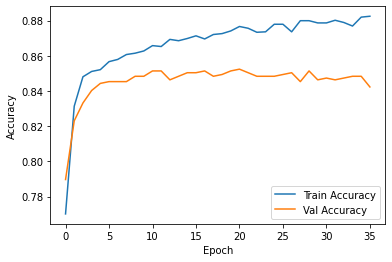

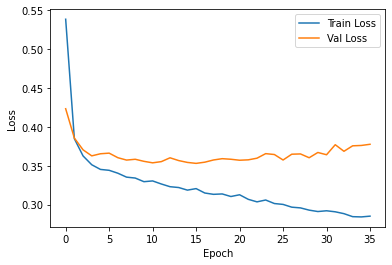

In [92]:
def plot_history(history):
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch
    
    plt.figure()
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.plot(hist['epoch'], hist['accuracy'], label='Train Accuracy')
    plt.plot(hist['epoch'], hist['val_accuracy'], label = 'Val Accuracy')
    plt.legend()
    
    plt.figure()
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.plot(hist['epoch'], hist['loss'], label='Train Loss')
    plt.plot(hist['epoch'], hist['val_loss'], label = 'Val Loss')
    plt.legend()
    plt.show()
    
plot_history(history_NN)

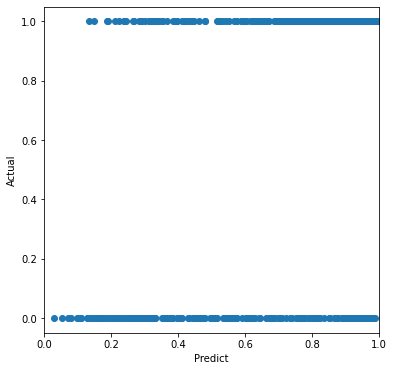

In [93]:
pred_NN = model_NN.predict(x_valid_nn)

plt.figure(figsize=(6, 6))
plt.xlabel("Predict")
plt.ylabel("Actual")
plt.xlim(0, 1)
plt.scatter(pred_NN, y_valid)
plt.show()

In [94]:
y_valid_array = np.array(y_valid).reshape(-1, 1)
y_valid_array.shape

(989, 1)

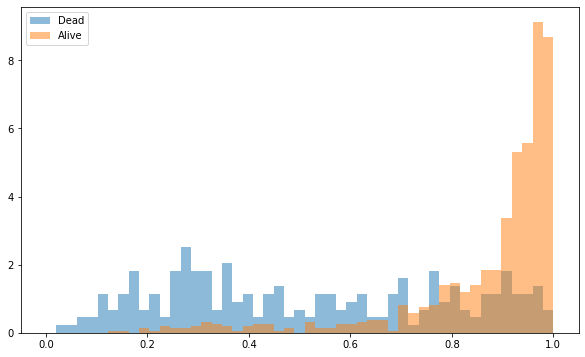

In [95]:
zero, one = [], []

for i in range(len(pred_NN)):
    if y_valid_array[i][0] == 0:
        zero.append(pred_NN[i][0])
    else:
        one.append(pred_NN[i][0])
        
plt.figure(figsize=(10, 6))
bins = np.linspace(0, 1, 50)

plt.hist(zero, bins, alpha = 0.5, label='Dead', density = True)
plt.hist(one, bins, alpha = 0.5, label='Alive', density = True)
plt.legend(loc='upper left')

plt.show()

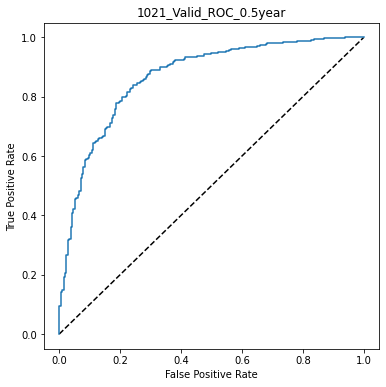

0.8663662039540894


In [96]:
# ROC曲線の値の生成：fpr、tpr、閾値
fpr, tpr, thresholds = roc_curve(y_valid, pred_NN)

# ROC曲線のプロット
plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr, label='Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('1021_Valid_ROC_1year')
#plt.savefig("1021_Valid_ROC_1year.jpg", dpi=300)
plt.show()

#AUCの表示
auc_NN = roc_auc_score(y_valid, pred_NN)
print(auc_NN)

# Total

In [97]:
pred_GBDT = pred_GBDT.reshape(-1, 1)
pred_GBDT.shape

(989, 1)

In [98]:
pred_NN.shape

(989, 1)

In [99]:
logloss_total = log_loss(y_valid_array, (pred_GBDT+pred_NN)/2)
logloss_total

0.3427433474309539

In [100]:
pred_total = (pred_NN+pred_GBDT)/2

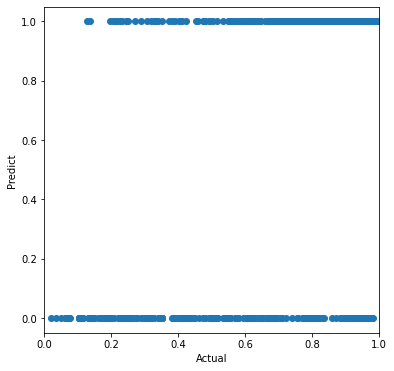

In [101]:
plt.figure(figsize=(6, 6))
plt.ylabel("Predict")
plt.xlabel("Actual")
plt.xlim(0, 1)
plt.scatter(pred_total, y_valid)
#plt.savefig("0716_Predict_Actual_Emsemble.jpg", dpi=300)
plt.show()

In [102]:
pred_total[0:5]

array([[0.9730395 ],
       [0.9813452 ],
       [0.965231  ],
       [0.97082955],
       [0.86910796]], dtype=float32)

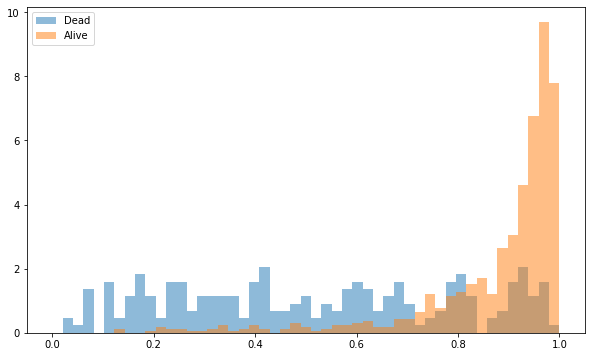

In [103]:
zero, one = [], []

for i in range(len(pred_total)):
    if y_valid_array[i][0] == 0:
        zero.append(pred_total[i][0])
    else:
        one.append(pred_total[i][0])
        
plt.figure(figsize=(10, 6))
bins = np.linspace(0, 1, 50)

plt.hist(zero, bins, alpha = 0.5, label='Dead', density = True)
plt.hist(one, bins, alpha = 0.5, label='Alive', density = True)
plt.legend(loc='upper left')

plt.show()

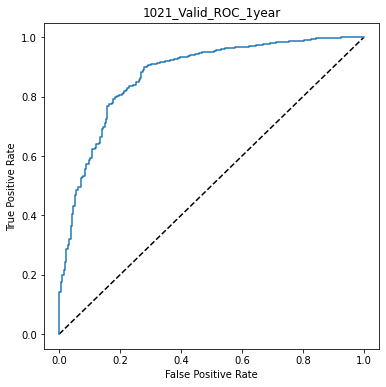

0.8742984195661319


In [104]:
# ROC曲線の値の生成：fpr、tpr、閾値
fpr, tpr, thresholds = roc_curve(y_valid, pred_total)

# ROC曲線のプロット
plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr, label='Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('1021_Valid_ROC_1year')
#plt.savefig("1021_Valid_ROC_1year.jpg", dpi=300)
plt.show()

#AUCの表示
auc_total = roc_auc_score(y_valid, pred_total)
print(auc_total)

In [105]:
confusion_matrix(y_valid.values.tolist(), np.round(pred_total).astype(int).tolist())

array([[105, 110],
       [ 36, 738]])

# Save

In [116]:
#pickle.dump(model_GBDT, open('models/0111_model_GBDT_1year.pickle', 'wb'))
#model_NN.save('models/1022_model_NN_1year.h5')